In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, QTable
from astropy.visualization import quantity_support
quantity_support()  


import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [183]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

## Data

### Orion Opacity, Temple SED

In [2]:
Orion_opacity = OpacityData.from_file('data/opacity_law/Orion.opc')
Temple_SED = SED.from_file('data/raw/quasar5.template')
# Temple_SED = SED.from_file('data/raw/quasar5_ly.template')

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


### Labbe photometric data

In [3]:
Labbe_photo_raw = Table.read('data/raw/Labbe_photo.dat', format='ascii', names=['lg_lambda', 'lg_nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': 10**Labbe_photo_raw['lg_lambda'] * u.micron, 
                      'nu_L_nu': 10**Labbe_photo_raw['lg_nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
# Labbe_photo.meta = {'z': 4.4655, }
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

In [4]:
Labbe_photo

wavelength_obs,nu_L_nu,wavelength_rest,nu_obs,nu_rest,Lnu_obs,Lnu_rest
micron,solLum,micron,Hz,Hz,solLum / Hz,solLum / Hz
float64,float64,float64,float64,float64,float64,float64
0.7019960960111995,8312047745.422186,0.1284413312617692,427057158442113.56,2334080899465371.0,1.9463548569807807e-05,3.561165230959256e-06
0.899984029546824,16837490832.18056,0.16466636712959914,333108642106634.75,1820605283433812.0,5.0546544591870847e-05,9.248292853695152e-06
1.1498548924823908,18624001274.96198,0.2103842086693607,260721991931335.03,1424976046900711.5,7.143241403228802e-05,1.3069694269927365e-05
1.4043754647291624,25203441893.940323,0.2569527883504094,213470304437293.62,1166721948902028.0,0.00011806532979084111,2.1601926592414442e-05
1.4930744380738064,25203441893.940323,0.27318167378534564,200788688330072.75,1097410576068012.4,0.00012552221991962446,2.296628303350553e-05
1.6235331166307188,22406032599.149887,0.2970511603020252,184654353477034.38,1009228368928731.2,0.00012134039721915652,2.220115217622478e-05
1.846840196204909,18624001274.96198,0.33790873592624815,162327232543479.72,887199489466388.4,0.00011473121905145212,2.099189809742057e-05
1.9765326632949234,30835507096.780453,0.3616380318900235,151675944226613.2,828984873170554.2,0.00020329859988021772,3.7196706592300384e-05


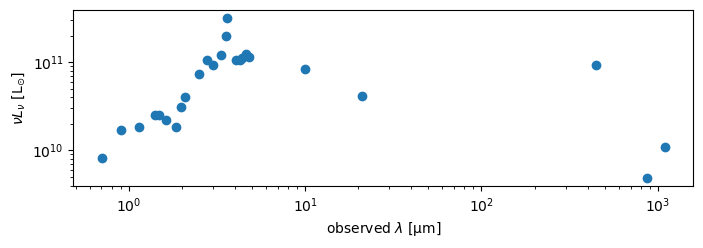

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x='wavelength_obs', y='nu_L_nu', data=Labbe_photo, )
ax.set_xlabel(fr'observed $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
# ax = plt.gca()

## 复刻之前的尝试

In [7]:
model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model

TypeError: Argument 'n_0' to function '__init__' has no 'unit' attribute. You should pass in an astropy Quantity instead.

In [ ]:
Orion_opacity.wavelength.to(u.Hz, u.spectral())

<Quantity [1.00166805e+07, 1.00501382e+07, 1.00836946e+07, ...,
           2.17777997e+22, 2.24393869e+22, 2.31210751e+22] Hz>

UnitConversionError: 'micron' (length) and 'Hz' (frequency) are not convertible

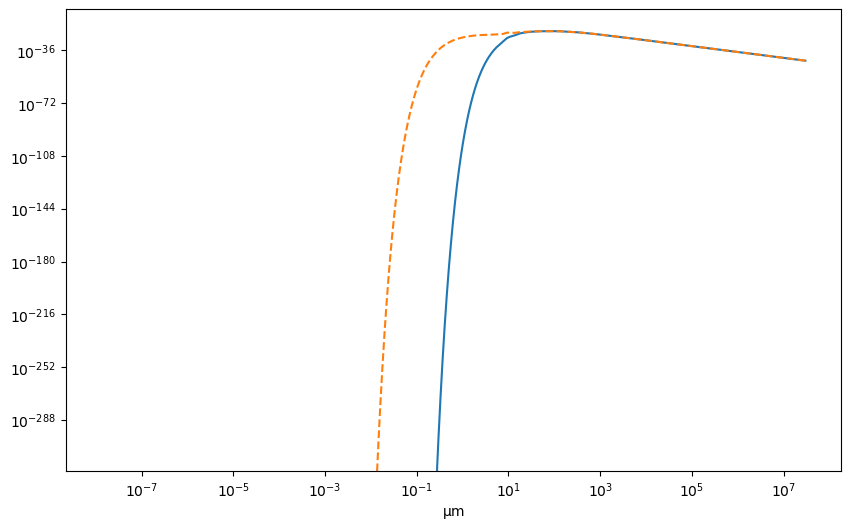

In [ ]:
def L_nu_contrast(L_nu_func, lambda_1, lambda_2):
    return np.log10( L_nu_func(lambda_1) / L_nu_func(lambda_2) )

def plot_L_nu(model: LRD_IR_ModelBase):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax: plt.Axes
    L_nu = model.calc_L_nu(r_sample_num=1000)
    L_nu_func = LogLogInterpolator(Orion_opacity.nu, L_nu) # 虽然 x 轴用的是 nu, 但由于启用了 u.spectral() 的等价关系，所以也可以用波长。
    ax.loglog(Orion_opacity.wavelength, L_nu, )
    model.tau_ph = 0
    L_nu_no_feedback = model.calc_L_nu(r_sample_num=1000)
    ax.loglog(Orion_opacity.wavelength, L_nu_no_feedback, '--', label='no feedback')
    
    
    # 对几个波段进行标注，计算对比度
    wavelength_points = [3, 10, 20, 300] * u.micron
    for wavelength in wavelength_points:
        y = L_nu_func(wavelength)
        lambda_1 = wavelength_points[0]
        lambda_2 = wavelength
        contrast = L_nu_contrast(L_nu_func, lambda_1, lambda_2)
        ax.scatter(wavelength, y, label = rf"$\log_{{10}}( L_{{{lambda_1.value}}}/L_{{{lambda_2.value}}} )$ = {contrast:.2f}")
        ax.annotate(f"{np.log10(y):.2f}", (wavelength.value, y), textcoords="offset points", xytext=(0, 10), ha='center')
        
        
    # 辅助线：sigma_H 和 multi-color BB
    sigma_H = Orion_opacity.sigma_H_abs.cgs.value
    ax.loglog(Orion_opacity.wavelength, L_nu / (sigma_H / sigma_H.max()), '-.', label=r'$L_\nu / Q_\nu$')
    ax.loglog(Orion_opacity.wavelength, (sigma_H / sigma_H.max()) * L_nu.max() , '-.', label=r'$Q_\nu \cdot \langle L_\nu \rangle$')
    
    # 设定坐标轴的范围
    ax.set_xlim(1e-1, 4e3)
    ax.set_ylim(L_nu.max() / 1e4, L_nu.max() * 1e2)
    
    # 坐标轴 label
    ax.set_xlabel(r"$\lambda$ [$\mu m$]")
    ax.set_ylabel(r"$L_\nu \ [{\rm erg/s}]$")
    
    # 上方的 T 轴
    def wavelength_to_temperature(x):
        return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x

    T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
    T_axis.set_xlabel(r"$T$ [K]")
    ax.axvline(wavelength_to_temperature(4 * model.T_out), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")
    
    # 添加图例
    ax.legend()
    ax.set_title(rf"{model:latex}")
    
    return fig, ax

# model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22)
model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
plot_L_nu(model)

In [ ]:
model = OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model

OrionLRDModel(n_0=40, gamma=0.4, L_UV=1e+46, T_sub=1500, r_in=0.8763944654691586)

In [ ]:
model.calc_L_nu().max()

1.5014295138373503e-23

In [ ]:
(Temple_SED.L_nu * u.erg/u.s/u.Hz * Temple_SED.nu).max()

<Quantity 2.01576488e+46 erg2 / (Hz s2)>

In [ ]:
arr = (Temple_SED.L_nu * u.erg/u.s/u.Hz)

In [ ]:
arr.unit

Unit("erg2 / (Hz2 s2)")

In [ ]:
(1 * u.erg).to(u.m)

<Quantity 1.98644586e-18 m>

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_IR_spectrum/src/LRD_IR_spectrum/model_base.py:24: RuntimeWarning: overflow encountered in exp
  return (2 * h / c**2) * nu**3 / (np.exp(x) - 1)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_IR_spectrum/src/LRD_IR_spectrum/utils.py:52: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


Text(0.5, 1.0, 'OrionLRDModel($n_0=$3.00e+02, $\\gamma=$0.5, \n    $T_{\\rm sub}=$1500, \n    $r_{\\rm in}=$8.76e-01, $r_{\\rm out}=$1.95e+03, $T_{\\rm out}=$32.2)\n    ')

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_44681/1500173958.py:30: RuntimeWarning: divide by zero encountered in divide
  return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x


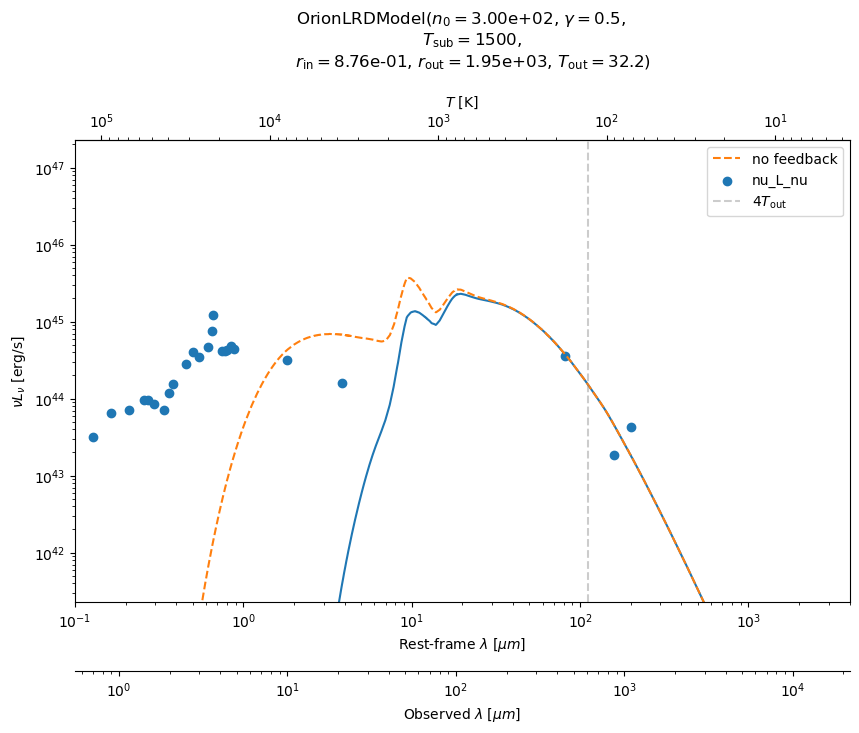

In [ ]:
model = OrionLRDModel(n_0=3e2, gamma=.5, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model_no_feedback = OrionLRDModel(n_0=3e2, gamma=.5, L_UV=1e46, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=Temple_SED)
model_no_feedback.tau_ph = 0.  # 暂时不考虑 feedback

fig, ax = plt.subplots(figsize=(10, 6))
L_nu_cgs = model.calc_L_nu(r_sample_num=1000) * u.pc.to(u.cm)**3
L_nu = L_nu_cgs * u.erg / u.s / u.Hz 
nu_L_nu = L_nu * Orion_opacity.nu

L_nu_cgs_no_feedback = model_no_feedback.calc_L_nu(r_sample_num=1000) * u.pc.to(u.cm)**3
L_nu_no_feedback = L_nu_cgs_no_feedback * u.erg / u.s / u.Hz 
nu_L_nu_no_feedback = L_nu_no_feedback * Orion_opacity.nu

ax.loglog(Orion_opacity.wavelength, nu_L_nu, )
ax.loglog(Orion_opacity.wavelength, nu_L_nu_no_feedback, '--', label='no feedback')

#TEMP
ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, )

# 设定坐标轴的范围
ax.set_xlim(1e-1, 4e3)
ax.set_ylim(nu_L_nu.cgs.value.max() / 1e4, nu_L_nu.cgs.value.max() * 1e2)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def wavelength_to_temperature(x):
    return (const.h * const.c / const.k_B).to(u.K * u.micron).value / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(wavelength_to_temperature(4 * model.T_out), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
ax.set_title(rf"{model:latex}")

In [ ]:
def foo():
    from astropy.constants import c, h, k_B
    return c/h

foo().unit.physical_type

PhysicalType('unknown')

## 限制 $A_V$

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_64841/2028788941.py:44: RuntimeWarning: divide by zero encountered in divide
  return (h * c / k_B).to_value(u.K * u.micron) / x


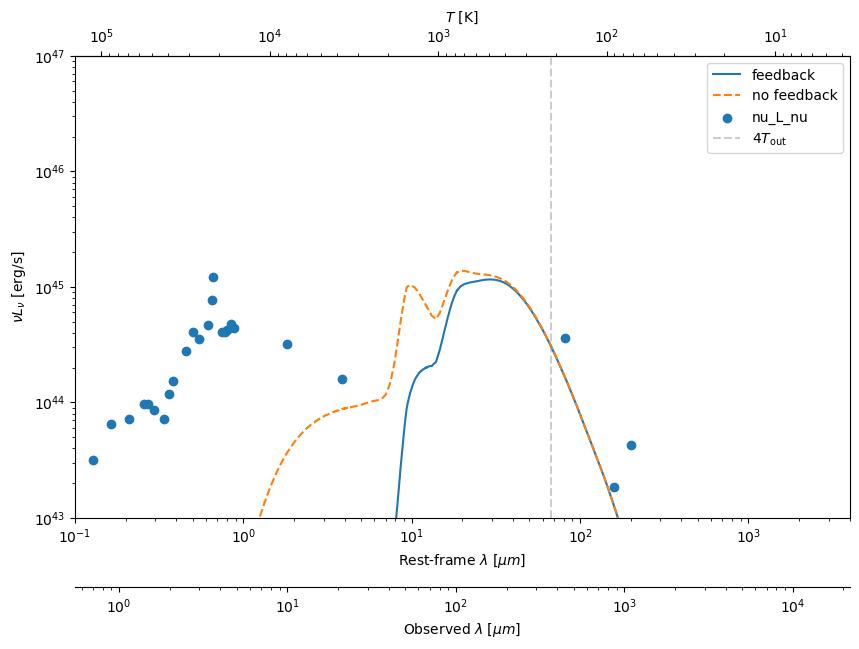

In [7]:
model = A_V_Model(
    n_0=80 * u.cm**-3,
    gamma=0.2,
    T_sub=1500 * u.K,
    A_V=2,
    opacity=Orion_opacity,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
)
model_no_feedback = A_V_Model(
    n_0=80 * u.cm**-3,
    gamma=0.2,
    T_sub=1500 * u.K,
    A_V=2,
    opacity=Orion_opacity,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
    tau_ph = 0, 
)
# model_no_feedback.T_min = 10 * u.K
# model_no_feedback.tau_ph = 0.  # 暂时不考虑 feedback

fig, ax = plt.subplots(figsize=(10, 6))

nu_L_nu = model.calc_nu_L_nu(r_sample_num=1000)
nu_L_nu_no_feedback = model_no_feedback.calc_nu_L_nu(r_sample_num=1000)

ax.loglog(Orion_opacity.wavelength, nu_L_nu, label='feedback')
ax.loglog(Orion_opacity.wavelength, nu_L_nu_no_feedback, '--', label='no feedback')

#TEMP
ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, )

# 设定坐标轴的范围
ax.set_xlim(1e-1, 4e3)
# ax.set_ylim(nu_L_nu.max() / 1e2, nu_L_nu.max() * 1e2)
ax.set_ylim(*[1e43, 1e47] * u.erg/u.s)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def wavelength_to_temperature(x):
    from astropy.constants import c, h, k_B
    return (h * c / k_B).to_value(u.K * u.micron) / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
# ax.set_title(rf"{model:latex}")

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_59716/912266019.py:36: RuntimeWarning: divide by zero encountered in divide
  return (h * c / k_B).to_value(u.K * u.micron) / x


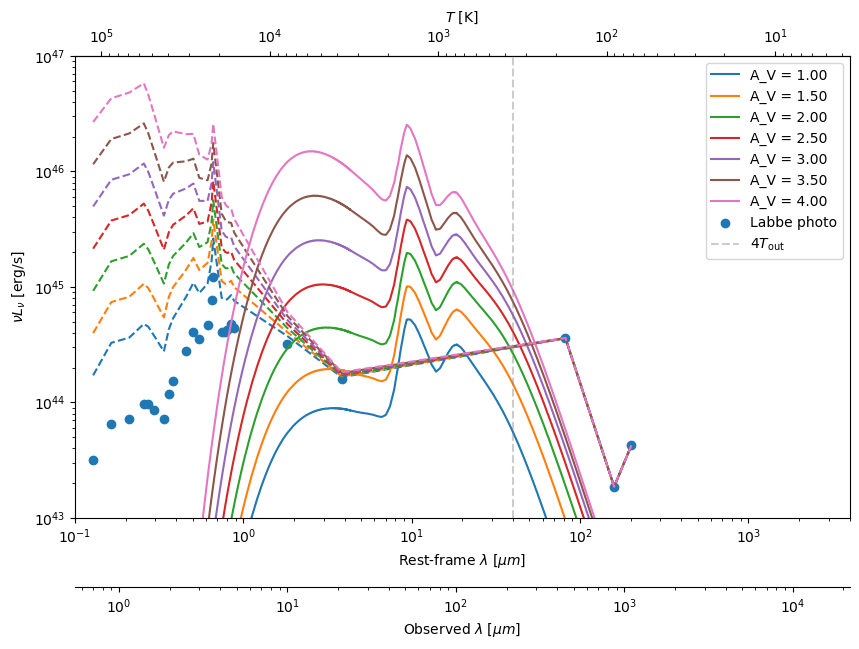

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for index, A_V in enumerate(np.arange(1, 4.5, .5)):
    model = A_V_Model(
        n_0=1e3 * u.cm**-3,
        gamma=0.5,
        T_sub=1500 * u.K,
        A_V=A_V,
        opacity=Orion_opacity,
        observed_SED=SED(Labbe_photo['nu_rest'], Labbe_photo['Lnu_rest']),
        tau_ph = 0,
    )

    nu_L_nu = model.calc_nu_L_nu(r_sample_num=1000)

    ax.loglog(Orion_opacity.wavelength, nu_L_nu, label=f'{A_V = :.2f}', color=color_cycle[index]) # IR 出射光谱
    
    ax.loglog(model.incident_SED.nu.to(u.um, u.spectral()), model.incident_SED.L_nu * model.incident_SED.nu, color=color_cycle[index], ls='--') #  de-reddened 入射光谱

#TEMP
ax.scatter('wavelength_rest', 'nu_L_nu', data=Labbe_photo, label='Labbe photo', )


# 设定坐标轴的范围
ax.set_xlim(*[1e-1, 4e3] * u.micron)
ax.set_ylim(*[1e43, 1e47] * u.erg/u.s)

# 坐标轴 label
ax.set_xlabel(r"Rest-frame $\lambda$ [$\mu m$]")
ax.set_ylabel(r"$\nu L_\nu \ [{\rm erg/s}]$")

# 上方的 T 轴
def wavelength_to_temperature(x):
    from astropy.constants import c, h, k_B
    return (h * c / k_B).to_value(u.K * u.micron) / x

T_axis = ax.secondary_xaxis('top', functions=(wavelength_to_temperature, wavelength_to_temperature))
T_axis.set_xlabel(r"$T$ [K]")
ax.axvline(wavelength_to_temperature(4 * model.T_out.to_value(u.K)), color='grey', alpha=.4, linestyle='--', label = r"$4 T_{\rm out}$")

z = Labbe_photo.meta['z']
T_axis = ax.secondary_xaxis(location=-.15, functions=(lambda x: x * (1+z), lambda x: x / (1+z)))
T_axis.set_xlabel(r"Observed $\lambda$ [$\mu m$]")

# 添加图例
ax.legend()
# ax.set_title(rf"{model:latex}")

In [89]:
model.incident_SED

## 检查能量平衡 Check Energy Balance

In [8]:
op = OpacityData(nu=Orion_opacity.nu, 
                 sigma_H_ext=Orion_opacity.sigma_H_ext)

model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3 * u.mag,
    opacity=op,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
    tau_ph=1
)
# model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [9]:
model.check_Luminosity()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

{'calc_L_from_extinction': <Quantity 1.41609096e+46 erg / s>,
 'calc_L_from_UV_Flux': <Quantity 1.41609062e+46 erg / s>,
 'calc_L_from_UV_Flux_with_feedback': <Quantity 9.80203558e+45 erg / s>,
 'calc_L_from_IR_Flux': <Quantity 9.80204135e+45 erg / s>,
 'calc_L_from_L_nu': <Quantity 9.80204135e+45 erg / s>}

In [9]:
# 验证 UV_Flux 和 IR_Flux 在各个 r 处都相等。没有 feedback 时成立，有 feedback 时不对
r_array = np.geomspace(model.r_in, model.r_out, 1000)
np.allclose(model.UV_Flux(r_array), model.IR_Flux(model.T_dust_profile(r_array)), rtol=1e-4, atol=0)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


False

In [10]:
np.allclose(model.UV_Flux_with_feedback(r_array), model.IR_Flux(model.T_dust_profile(r_array)), rtol=1e-4, atol=0)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


True

### feedback 的 T_profile 

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in 

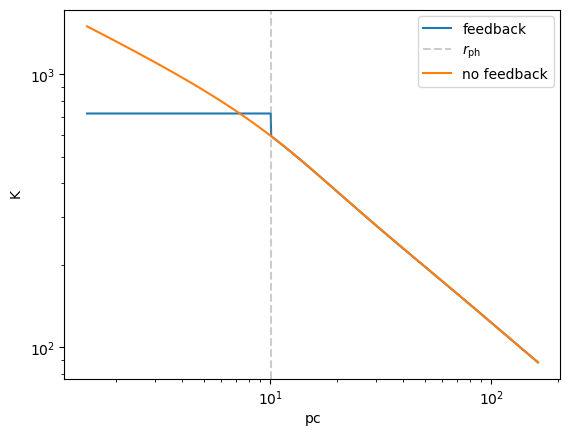

In [10]:
model = A_V_Model(
    n_0=1e3 * u.cm**-3,
    gamma=0.5,
    T_sub=1500 * u.K,
    A_V=3.5,
    opacity=Orion_opacity,
    observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']),
    # tau_ph=0,
)


r_array = np.geomspace(model.r_in, model.r_out, 1000)
plt.loglog(r_array, model.T_dust_profile(r_array), label='feedback')
plt.axvline(model.r_ph, color='grey', alpha=.4, linestyle='--', label = r"$r_{\rm ph}$")
model.tau_ph = 0
plt.loglog(r_array, model.T_dust_profile(r_array), label='no feedback')
plt.legend()

## 临时测试

### mag

### 图例

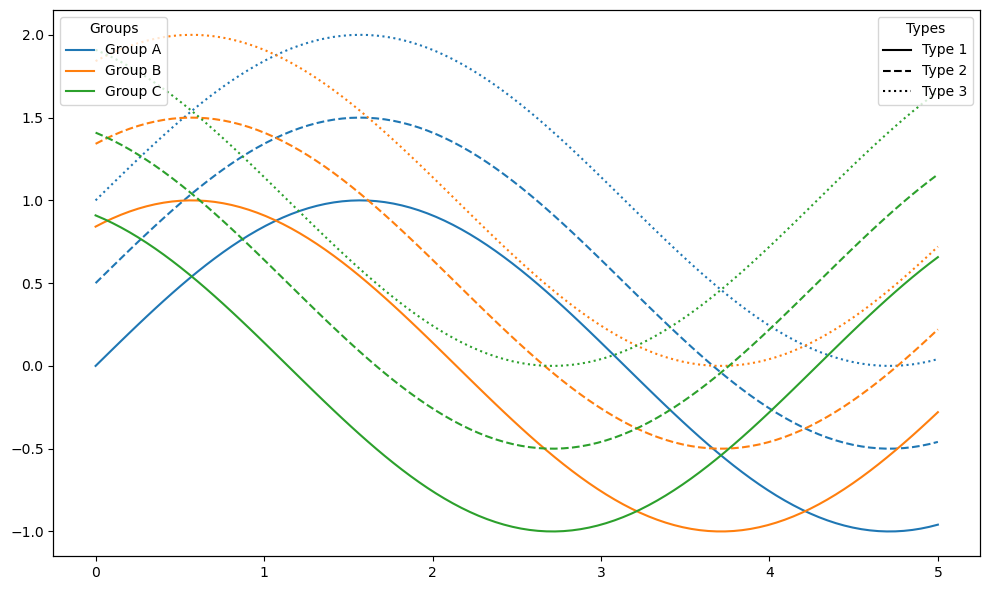

In [131]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))

# 定义分组和类型
groups = ['Group A', 'Group B', 'Group C']
types = ['Type 1', 'Type 2', 'Type 3']

# 定义样式
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
linestyles = ['-', '--', ':']

# 生成数据并绘图
x = np.linspace(0, 5, 100)
lines = []

for g_idx, group in enumerate(groups):
    group_lines = []
    for t_idx, type_name in enumerate(types):
        y = np.sin(x + g_idx) + t_idx * 0.5
        line, = ax.plot(x, y, color=colors[g_idx], linestyle=linestyles[t_idx])
        group_lines.append(line)
    lines.append(group_lines)

# 创建自定义图例 - 分成两部分
# 1. 组别图例
group_handles = [mlines.Line2D([], [], color=color, linestyle='-', 
                              label=group) for color, group in zip(colors, groups)]
# 2. 类型图例
type_handles = [mlines.Line2D([], [], color='black', linestyle=ls, 
                             label=type_name) for ls, type_name in zip(linestyles, types)]

# 添加两组图例
ax.legend(handles=group_handles, loc='upper left', title='Groups')
# 添加第二个图例框
ax2 = ax.twinx()
ax2.set_yticks([])
ax2.legend(handles=type_handles, loc='upper right', title='Types')

plt.tight_layout()

In [114]:
group_handles